# Import Libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Load Dataset

In [2]:
df = pd.read_csv("bank-additional-full.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# Data Understanding

In [6]:
df.columns
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

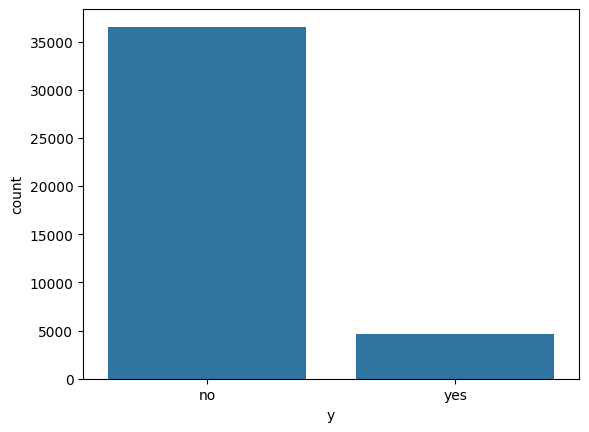

In [7]:
sns.countplot(x='y', data=df)
plt.show()

# Exploratory Data Analysis (EDA)

# Missing values

In [8]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

# Numerical distribution

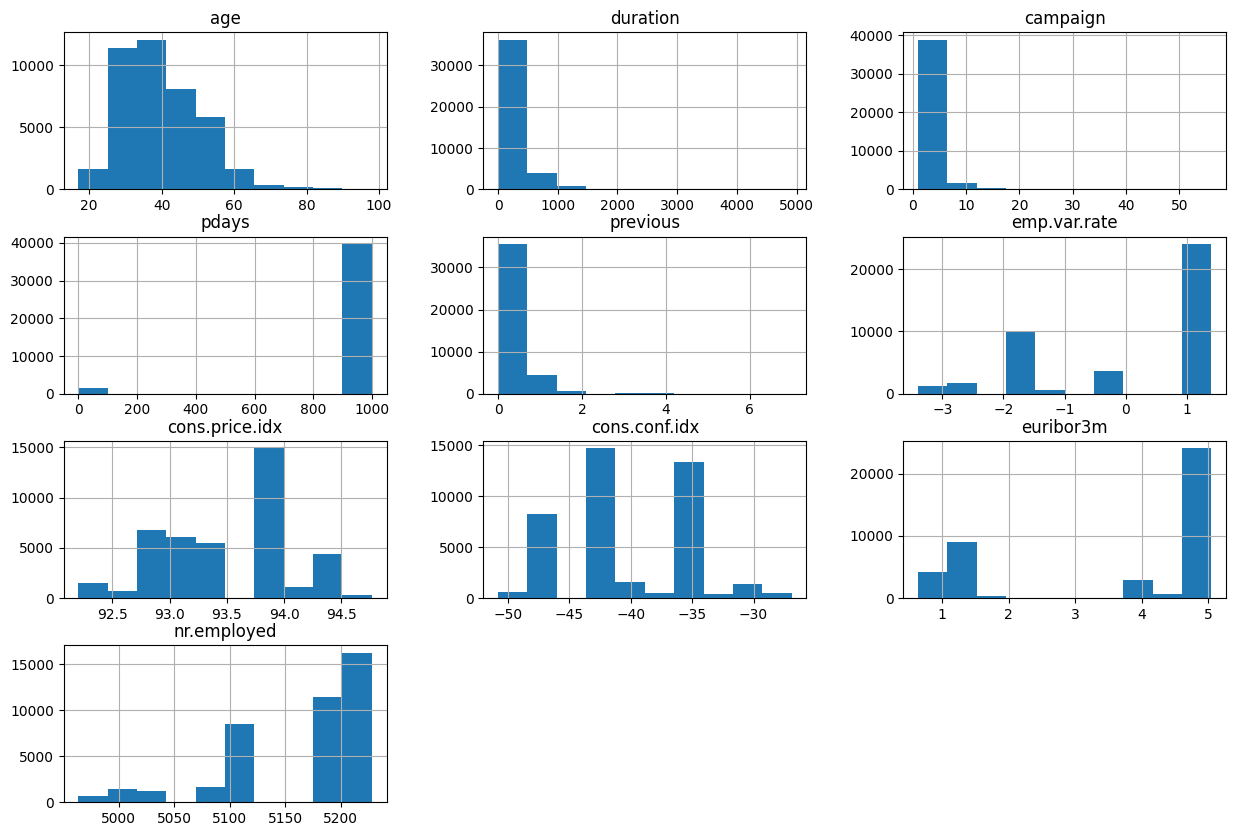

In [9]:
df.hist(figsize=(15,10))
plt.show()

# Correlation heatmap

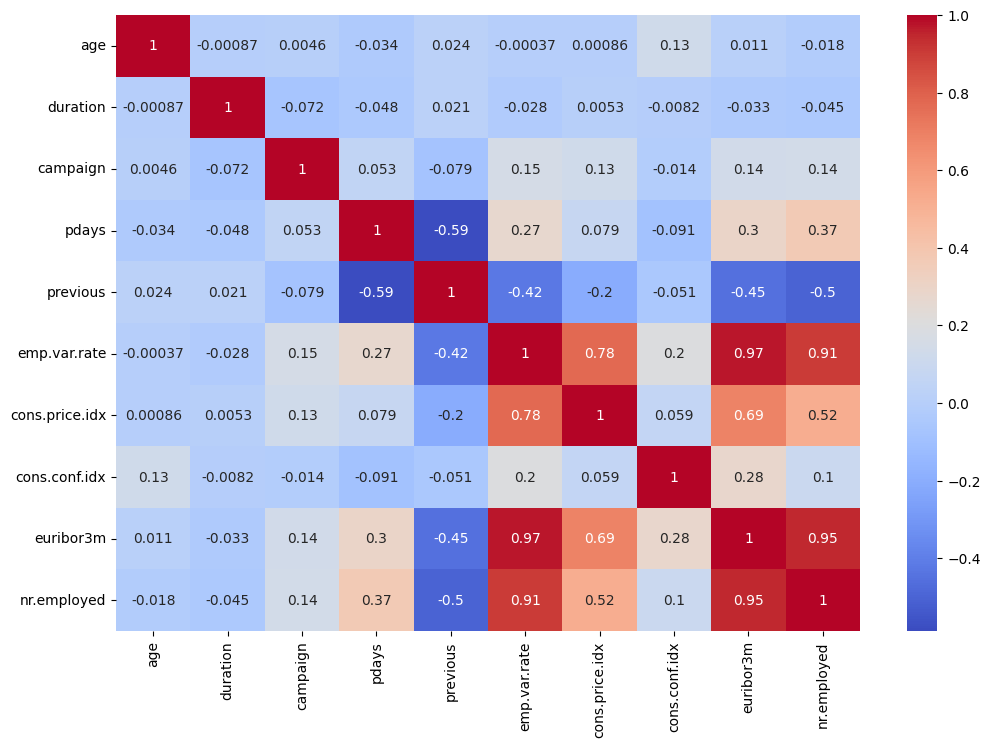

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

#  Data Cleaning

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.drop('duration', axis=1, inplace=True)
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [13]:
df.replace('unknown', np.nan, inplace=True)
df.fillna(method='ffill', inplace=True)

C:\Users\tauff\AppData\Local\Temp\ipykernel_29760\2779592924.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


# Feature Engineering (Encoding)

In [14]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Split Features and Target

In [15]:
X = df.drop('y', axis=1)
y = df['y']

# Feature Scaling

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_scaled

array([[ 1.53314313, -0.18830539, -0.27957101, ...,  0.88656813,
         0.71246263,  0.33169507],
       [ 1.62910732,  0.93880333, -0.27957101, ...,  0.88656813,
         0.71246263,  0.33169507],
       [-0.29017656,  0.93880333, -0.27957101, ...,  0.88656813,
         0.71246263,  0.33169507],
       ...,
       [ 1.53314313,  0.37524897, -0.27957101, ..., -2.22505906,
        -1.49519696, -2.81568858],
       [ 0.3815728 ,  1.5023577 , -0.27957101, ..., -2.22505906,
        -1.49519696, -2.81568858],
       [ 3.26049862,  0.37524897, -0.27957101, ..., -2.22505906,
        -1.49519696, -2.81568858]], shape=(41176, 19))

# Train Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
X_test

array([[-0.48210494,  0.93880333, -0.27957101, ..., -0.28029207,
         0.71649858,  0.84518642],
       [-0.96192591,  1.22058052,  1.37558585, ...,  0.64887438,
        -1.58052828, -2.81568858],
       [-0.29017656,  0.65702615,  1.37558585, ..., -1.23106704,
        -1.37065936, -0.94026868],
       ...,
       [-1.82560366,  1.22058052,  1.37558585, ..., -1.23106704,
        -1.34932653, -0.94026868],
       [-0.19421236,  1.5023577 ,  1.37558585, ...,  0.88656813,
         0.71130951,  0.33169507],
       [-0.86596172,  0.93880333, -0.27957101, ..., -0.47476877,
         0.77184862,  0.84518642]], shape=(8236, 19))

In [20]:
y_train

36454    0
1233     1
24111    0
15516    0
17916    0
        ..
33267    0
22714    1
6971     0
18503    0
24790    0
Name: y, Length: 32940, dtype: int64

# Model Building

#### Logistic Regression

In [21]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [22]:
lr_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(8236,))

#### Decision Tree

In [23]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [24]:
dt_pred

array([0, 1, 0, ..., 1, 0, 1], shape=(8236,))

#### Random Forest

In [25]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [26]:
rf_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(8236,))

#### KNN

In [27]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

In [28]:
knn_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(8236,))

#### Support Vector Machine

In [29]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [30]:
svm_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(8236,))

#### Model Evaluation

In [31]:
def evaluate_model(name, y_true, y_pred):
    print("Model:", name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("-"*40)

In [32]:
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("KNN", y_test, knn_pred)
evaluate_model("SVM", y_test, svm_pred)

Model: Logistic Regression
Accuracy: 0.8993443419135503
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7308
           1       0.67      0.21      0.32       928

    accuracy                           0.90      8236
   macro avg       0.79      0.60      0.63      8236
weighted avg       0.88      0.90      0.88      8236

[[7213   95]
 [ 734  194]]
----------------------------------------
Model: Decision Tree
Accuracy: 0.8443419135502671
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      7308
           1       0.33      0.36      0.34       928

    accuracy                           0.84      8236
   macro avg       0.62      0.63      0.63      8236
weighted avg       0.85      0.84      0.85      8236

[[6620  688]
 [ 594  334]]
----------------------------------------
Model: Random Forest
Accuracy: 0.8950947061680428
              precision    recall  f1-score   support


# Model Comparison Table

In [33]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","KNN","SVM"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
4,SVM,0.900801
0,Logistic Regression,0.899344
3,KNN,0.895945
2,Random Forest,0.895095
1,Decision Tree,0.844342


### ROC Curve (Best Model Example: Random Forest)

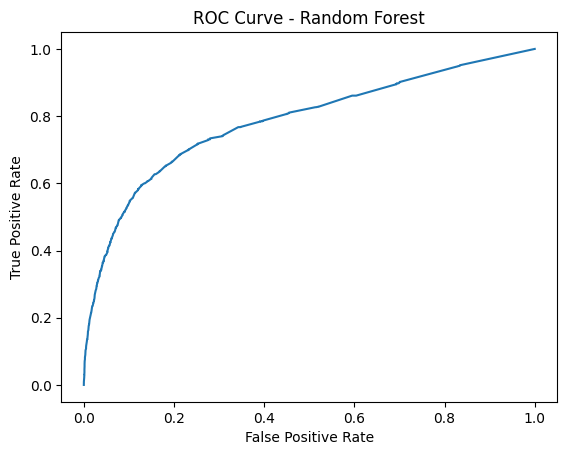

AUC Score: 0.784365607246664


In [34]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

### Feature Importance

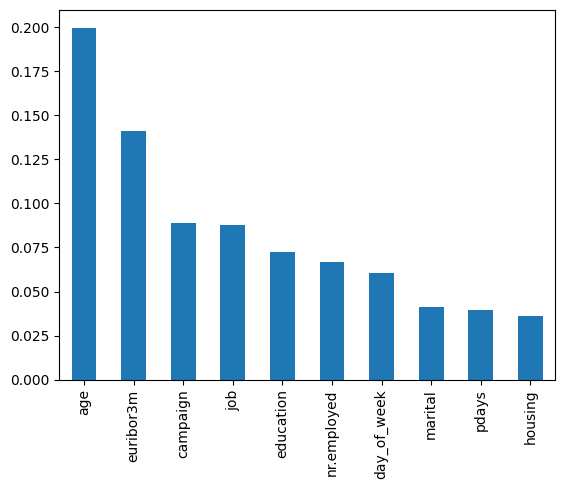

In [35]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.show()

# PROJECT REPORT 

### Predicting Term Deposit Subscription Using Machine Learning
#### (Portuguese Bank Marketing Campaign Analysis)

## 1. ABSTRACT
#### This project aims to develop a predictive machine learning model to determine whether a customer will subscribe to a term deposit based on demographic, economic, and campaign-related features. The dataset used for this study is sourced from the UCI Machine Learning Repository Bank Marketing dataset, which contains real-world marketing campaign data from a Portuguese banking institution.

#### The project involves data preprocessing, exploratory data analysis (EDA), feature engineering, model building, evaluation, and business interpretation. Multiple machine learning algorithms were implemented and compared to identify the best-performing model. The final system provides actionable insights to improve marketing efficiency and reduce operational costs


## 2.INTRODUCTION

### Marketing campaigns are essential for financial institutions to promote term deposits and other banking products. However, traditional telemarketing strategies often result in:
### .High operational cost
### .Low conversion rate
### .Customer dissatisfaction
### Using machine learning, we can predict customer responses before contacting them. This enables targeted marketing strategies that improve efficiency and profitability.

# 3. PROBLEM STATEMENT
## To build a classification model that predicts whether a customer will subscribe to a term deposit (Yes/No) based on available customer and campaign data.
### Target Variable:
### Code:
#### y → yes / no


### Objective:
### .Maximize prediction accuracy
### .Improve recall for "Yes" class
### .Reduce unnecessary marketing calls


## 4.DATASET DESCRIPTION
### Source: UCI Machine Learning Repository
### Dataset: Portuguese Bank Marketing Dataset
## Dataset Characteristics:
### . Type: Classification
### . Number of Features: 16+
### . Target Variable: Subscription (y)
### . Data Type: Categorical + Numerical
### . Class Imbalance: Yes (minority class)


# 5. METHODOLOGY
The project follows a structured machine learning pipeline:
## Step 1: Data Loading
#### . Load dataset using Pandas
#### . Inspect structure with .info() and .describe()
## Step 2: Data Cleaning
#### . Checked for missing values
#### . Handled categorical inconsistencies
#### . Verified data types
## Step 3: Exploratory Data Analysis (EDA)
#### . Class distribution analysis
#### . Correlation heatmap
#### . Boxplots for outlier detection
#### . Category-wise subscription comparison




# 6.Exploratory Data Analysis (EDA)
### 6.1 Class Distribution
### The dataset is imbalanced
#### . Majority class: No
#### . Minority class: Yes
This indicates fewer customers subscribe to term deposits.

## 6.2 Key Observations
### 1. Customers with longer call duration have higher subscription probability.
### 2. Customers without housing loans are more likely to subscribe.
### 3. Previous campaign success increases chances of subscription.
### 4. Balance and age influence customer decision behavior.

## 6.3 Correlation Analysis
### . Duration shows strong positive correlation with subscription.
### . Campaign contacts beyond a limit reduce success probability.


## 7. Model Building
The following machine learning models were implemented:
### 7.1 Logistic Regression
### . Baseline classification model
### . Works well for binary classification
### . Easy to interpret

### 7.2 Decision Tree Classifier
### . Captures nonlinear relationships
### . Provides feature importance

### 7.3 Random Forest Classifier
### . Ensemble method
### . Reduces overfitting
### . Improves accuracy

### 7.4 (If Applied) Other Models
### . K-Nearest Neighbors
### . Support Vector Machine

### 8. Model Evaluation
### Evaluation metrics used:
### . Accuracy
### . Precision
### . Recall
### . F1-Score
### . Confusion Matrix1

### Important Insight:
Since the dataset is imbalanced:
### . Recall and F1-score are more important than accuracy.

### 9. Results
#### . Random Forest performed better compared to other models.
#### . Logistic Regression provided good baseline performance.
#### . Decision Tree showed slight overfitting.
### . Best Model: Random Forest Classifier
### Reasons:
### . Handles non-linearity
### . Robust against noise
### . Works well with mixed data types

### 10. Feature Importance
Top influencing features:
#### 1. Duration of call
#### 2. Previous campaign outcome
#### 3. Balance
#### 4. Number of contacts
#### 5. Housing loan status
This suggests that campaign-related features strongly impact subscription decisions.

## 11. Business Insights
#### 1. Focus on customers with positive previous campaign outcomes.
#### 2. Improve call quality and engagement (duration matters).
#### 3. Avoid excessive repeated calls to the same customer.
#### 4. Target customers without housing loans for better conversion rates.

## 12. Limitations
#### . Dataset imbalance affects prediction.
#### . Duration is known only after call completion (not useful for pre-call prediction).
#### . Real-time external factors not included.

## 13. Future Enhancements
#### . Apply SMOTE for handling imbalance.
#### . Use XGBoost or Gradient Boosting for better performance.
#### . Deploy model using Flask/Streamlit.
#### . Integrate real-time customer scoring system.

## 14. Conclusion
This project successfully analyzed the Portuguese Bank Marketing dataset and built predictive models to classify customer subscription behavior.
### Key achievements:
#### . Performed comprehensive EDA
#### . Preprocessed data effectively
#### . Built multiple ML models
#### . Identified key business insights
#### . Improved campaign targeting strategy
## The model can help banks:
#### . Reduce marketing costs
#### . Increase subscription rates
#### . Improve campaign efficiency